# Tutorial 03: Signal Processing and Frequency Analysis
## Master Time-Domain EPR Analysis with EPyR Tools

Welcome to the third EPyR Tools tutorial! Time-domain EPR techniques like Rabi oscillations, echo sequences, and relaxation measurements require sophisticated signal processing. This notebook explores the new `signalprocessing` module.

### 🎯 Learning Objectives

By the end of this tutorial, you will:
- Understand time-domain EPR signal characteristics
- Apply FFT-based frequency analysis with proper DC offset removal
- Use apodization windows to improve spectral quality
- Analyze Rabi oscillations and extract frequencies
- Process echo decay and coherence time measurements
- Create publication-quality time-frequency plots

### 🌊 Time-Domain EPR Techniques

Modern pulsed EPR includes:
- **Rabi Oscillations**: Coherent spin control frequency analysis
- **Echo Sequences**: T2 relaxation and coherence measurements
- **DEER/PELDOR**: Distance measurements via modulation analysis
- **Relaxation**: T1 recovery and decay processes

Let's dive into real time-domain EPR data!

## 🚀 Setup and Module Exploration

First, let's explore the new signal processing capabilities in EPyR Tools v0.2.0:

In [3]:
# Essential imports
import epyr
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Configure matplotlib for better plots
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['lines.linewidth'] = 2

print(f"EPyR Tools Version: {epyr.__version__}")
print(f"Signal processing module: {hasattr(epyr, 'signalprocessing')}")

# Explore signal processing functions
print("\nAvailable signal processing functions:")
if hasattr(epyr, 'signalprocessing'):
    sp_functions = [func for func in dir(epyr.signalprocessing) if not func.startswith('_')]
    for func in sp_functions:
        print(f"  - {func}")
        
    # Import specific functions
    from epyr.signalprocessing import analyze_frequencies, power_spectrum, spectrogram_analysis
    print("\n✅ Key functions imported successfully!")
else:
    print("❌ Signal processing module not available")

# Set up data path
data_path = Path('../data')
print(f"\nData directory exists: {data_path.exists()}")

EPyR Tools Version: 0.2.0
Signal processing module: True

Available signal processing functions:
  - analyze_frequencies
  - analyze_frequencies_2d
  - apowin
  - apply_window_demo
  - frequency_analysis
  - frequency_response_demo
  - power_spectrum
  - spectrogram_analysis
  - window_comparison

✅ Key functions imported successfully!

Data directory exists: True


## 📊 Example 1: Rabi Oscillation Analysis

Rabi oscillations are a fundamental quantum phenomenon in EPR. Let's load and analyze real Rabi data from Yb³⁺ in CaWO4:

Loading Rabi data: 2024_08_CaWO4171Yb_rabi_6K_6724G_18dB.DSC


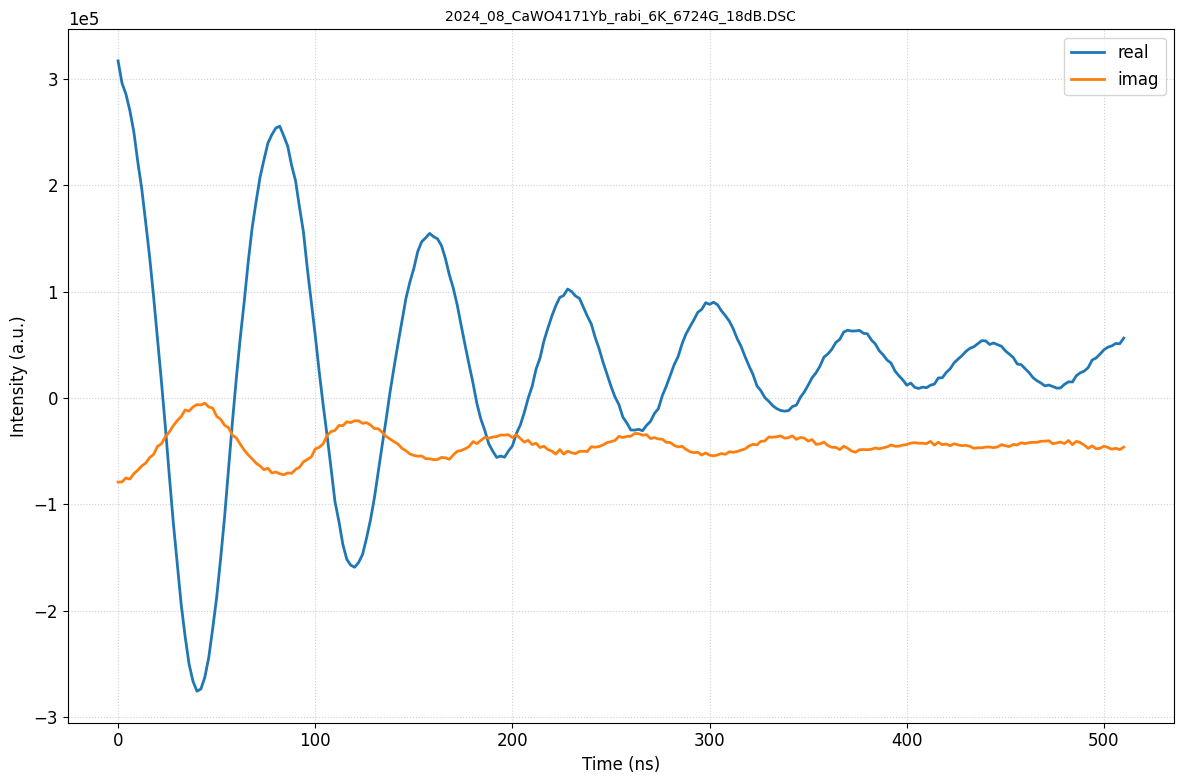


Rabi Data Information:
Time points: 256
Time range: 0.0 to 510.0 ns
Time step: 2.00 ns
Signal type: Complex
Microwave frequency: 9762911000.0 GHz
Magnetic field: 0.6725 G


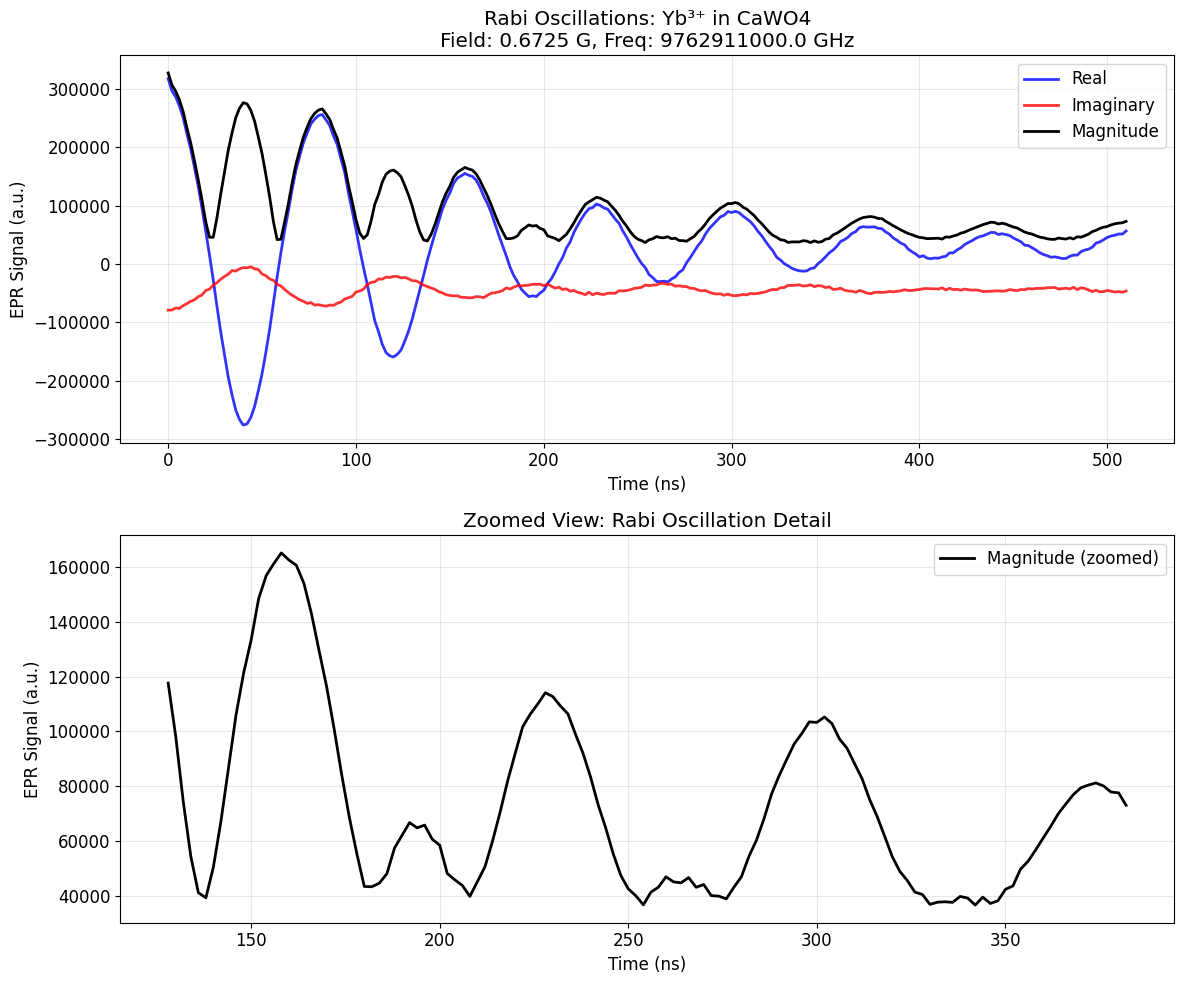

✅ Rabi data loaded and visualized!


In [2]:
# Load Rabi oscillation data
rabi_file = data_path / '2024_08_CaWO4171Yb_rabi_6K_6724G_18dB.DSC'

if rabi_file.exists():
    print(f"Loading Rabi data: {rabi_file.name}")
    time, signal, params, filepath = epyr.eprload(str(rabi_file))
    
    print(f"\nRabi Data Information:")
    print(f"Time points: {len(time)}")
    print(f"Time range: {time.min():.1f} to {time.max():.1f} ns")
    print(f"Time step: {np.mean(np.diff(time)):.2f} ns")
    print(f"Signal type: {'Complex' if np.iscomplexobj(signal) else 'Real'}")
    print(f"Microwave frequency: {params.get('MWFQ', 'Unknown')} GHz")
    print(f"Magnetic field: {params.get('B0VL', 'Unknown')} G")
    
    # Initial visualization
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
    
    # Plot time-domain signal
    if np.iscomplexobj(signal):
        ax1.plot(time, np.real(signal), 'b-', alpha=0.8, label='Real')
        ax1.plot(time, np.imag(signal), 'r-', alpha=0.8, label='Imaginary')
        ax1.plot(time, np.abs(signal), 'k-', linewidth=2, label='Magnitude')
        signal_for_analysis = signal  # Use complex signal
    else:
        ax1.plot(time, signal, 'b-', linewidth=1.5, label='Rabi Signal')
        signal_for_analysis = signal
    
    ax1.set_xlabel('Time (ns)')
    ax1.set_ylabel('EPR Signal (a.u.)')
    ax1.set_title(f'Rabi Oscillations: Yb³⁺ in CaWO4\nField: {params.get("B0VL", "Unknown")} G, Freq: {params.get("MWFQ", "Unknown")} GHz')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # Zoomed view of oscillations
    zoom_start = len(time) // 4
    zoom_end = 3 * len(time) // 4
    
    if np.iscomplexobj(signal):
        ax2.plot(time[zoom_start:zoom_end], np.abs(signal)[zoom_start:zoom_end], 
                'k-', linewidth=2, label='Magnitude (zoomed)')
    else:
        ax2.plot(time[zoom_start:zoom_end], signal[zoom_start:zoom_end], 
                'b-', linewidth=2, label='Signal (zoomed)')
    
    ax2.set_xlabel('Time (ns)')
    ax2.set_ylabel('EPR Signal (a.u.)')
    ax2.set_title('Zoomed View: Rabi Oscillation Detail')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Rabi data loaded and visualized!")
    
else:
    print("❌ Rabi data file not found")
    # Create synthetic Rabi data for demonstration
    print("Creating synthetic Rabi oscillation data...")
    
    time = np.linspace(0, 500, 256)  # 500 ns, 256 points
    rabi_freq = 8.5  # MHz
    decay_time = 120  # ns
    noise_level = 0.04
    
    # Create Rabi signal with decay
    clean_signal = np.sin(2 * np.pi * rabi_freq * time * 1e-3) * np.exp(-time/decay_time)
    signal = clean_signal + noise_level * np.random.randn(len(time))
    signal_for_analysis = signal
    
    # Fake parameters
    params = {'MWFQ': 9.4, 'B0VL': 6724, 'Temperature': 6}
    
    # Plot synthetic data
    plt.figure(figsize=(12, 6))
    plt.plot(time, signal, 'b-', linewidth=1.5, label=f'Synthetic Rabi (f={rabi_freq} MHz)')
    plt.plot(time, clean_signal, 'r--', alpha=0.7, label='Clean signal')
    plt.xlabel('Time (ns)')
    plt.ylabel('EPR Signal (a.u.)')
    plt.title('Synthetic Rabi Oscillation Data')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
    
    print(f"✅ Synthetic Rabi data created (target frequency: {rabi_freq} MHz)")

## 🔍 FFT-Based Frequency Analysis

Now let's use the new `analyze_frequencies` function to extract the Rabi frequency with proper DC offset removal and windowing:

In [3]:
# Perform comprehensive FFT analysis
print("🔍 FFT-Based Rabi Frequency Analysis")
print("=" * 50)

# Apply FFT analysis with DC removal and windowing
result = analyze_frequencies(
    time, signal_for_analysis,
    window='hann',           # Hann window for good frequency resolution
    zero_padding=4,          # 4x zero padding for better frequency resolution
    remove_dc=True,          # Essential for clean spectra
    plot=True,               # Generate comprehensive plots
    freq_range=(0, 20)       # Focus on 0-20 MHz range for Rabi frequencies
)

# Extract results
frequencies = result['frequencies']
power_spectrum = result['power_spectrum']
dominant_frequencies = result['dominant_frequencies']
freq_unit = result['freq_unit']
time_unit = result['time_unit']

print(f"\n📊 Analysis Results:")
print(f"Frequency resolution: {frequencies[1] - frequencies[0]:.6f} {freq_unit}")
print(f"Time unit detected: {time_unit}")
print(f"Frequency unit: {freq_unit}")

if len(dominant_frequencies) > 0:
    print(f"\n🎯 Dominant Frequencies Detected:")
    for i, freq in enumerate(dominant_frequencies[:5]):
        # Find the power at this frequency
        freq_idx = np.argmin(np.abs(frequencies - freq))
        power_pct = power_spectrum[freq_idx] * 100
        print(f"  {i+1}. {freq:.6f} {freq_unit} (power: {power_pct:.1f}%)")
    
    # Primary Rabi frequency
    rabi_frequency = dominant_frequencies[0]
    print(f"\n⚡ Primary Rabi Frequency: {rabi_frequency:.6f} {freq_unit}")
    
    # Calculate Rabi pulse parameters
    print(f"\n🔬 Rabi Pulse Analysis:")
    pi_pulse_time = 0.5 / rabi_frequency  # Half period for π pulse
    pi_2_pulse_time = pi_pulse_time / 2   # Quarter period for π/2 pulse
    
    if time_unit == 'ns':
        print(f"  π pulse time: {pi_pulse_time * 1000:.1f} ns")
        print(f"  π/2 pulse time: {pi_2_pulse_time * 1000:.1f} ns")
    else:
        print(f"  π pulse time: {pi_pulse_time:.3f} {time_unit}")
        print(f"  π/2 pulse time: {pi_2_pulse_time:.3f} {time_unit}")
        
else:
    print("⚠️ No dominant frequencies detected")

print("\n✅ FFT frequency analysis complete!")

🔍 FFT-Based Rabi Frequency Analysis


NameError: name 'analyze_frequencies' is not defined

## 🪟 Window Function Comparison

Different apodization windows affect spectral analysis. Let's compare their effects on Rabi frequency detection:

🪟 Window Function Comparison for Rabi Analysis

Testing hann window...
FFT Analysis of 256 data points
Time unit: ns, Frequency unit: MHz
Sampling rate: 500.0 MHz
Removed DC offset: 30919.246094-44049.132812j
Applied hann window
Zero padding: 256 -> 1024 points

Frequency Analysis Results:
Frequency resolution: 0.488281 MHz
Maximum frequency: 249.512 MHz

Dominant frequencies (MHz):
  1. 13.671875 MHz (power: 100.0%)
  Primary frequency: 13.671875 MHz
  Spectral resolution (FWHM): 3.417969 MHz

Testing hamming window...
FFT Analysis of 256 data points
Time unit: ns, Frequency unit: MHz
Sampling rate: 500.0 MHz
Removed DC offset: 30919.246094-44049.132812j
Applied hamming window
Zero padding: 256 -> 1024 points

Frequency Analysis Results:
Frequency resolution: 0.488281 MHz
Maximum frequency: 249.512 MHz

Dominant frequencies (MHz):
  1. 13.671875 MHz (power: 100.0%)
  Primary frequency: 13.671875 MHz
  Spectral resolution (FWHM): 2.929688 MHz

Testing blackman window...
FFT Analysis of

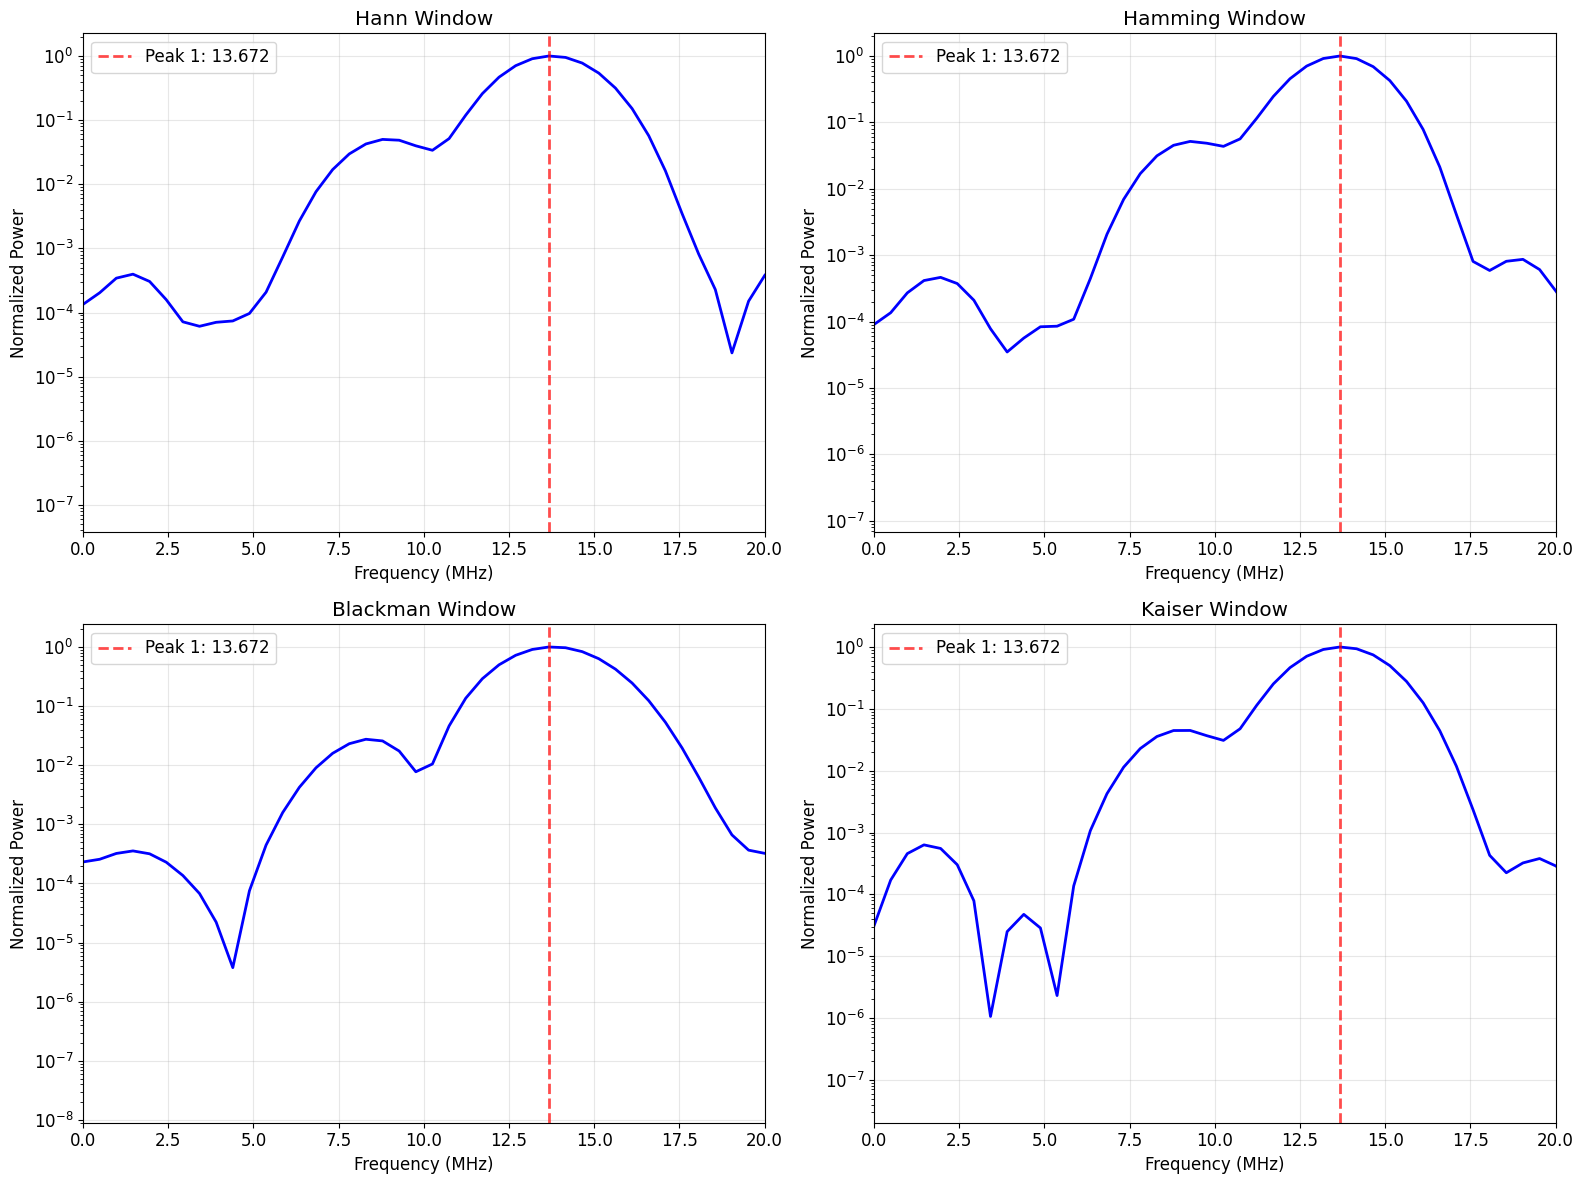


📊 Window Function Summary:
Window       Primary Freq    Peak Count   Comments            
------------ --------------- ------------ --------------------
hann         13.671875       1            Good balance        
hamming      13.671875       1            Low sidelobes       
blackman     13.671875       1            Excellent sidelobes 
kaiser       13.671875       1            Adjustable α=6      

🎯 Recommendation: Hann window provides good balance of resolution and sidelobe suppression

✅ Window function comparison complete!


In [4]:
# Compare different window functions
windows_to_test = ['hann', 'hamming', 'blackman', 'kaiser']
window_results = {}

print("🪟 Window Function Comparison for Rabi Analysis")
print("=" * 55)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, window in enumerate(windows_to_test):
    print(f"\nTesting {window} window...")
    
    # Special parameter for Kaiser window
    window_alpha = 6.0 if window == 'kaiser' else None
    
    try:
        result = analyze_frequencies(
            time, signal_for_analysis,
            window=window,
            window_alpha=window_alpha,
            zero_padding=4,
            remove_dc=True,
            plot=False,  # We'll create our own plots
            freq_range=(0, 20)
        )
        
        window_results[window] = result
        
        # Plot power spectrum for this window
        ax = axes[i]
        ax.semilogy(result['frequencies'], result['power_spectrum'], 'b-', linewidth=2)
        
        # Mark dominant frequencies
        for j, freq in enumerate(result['dominant_frequencies'][:3]):
            ax.axvline(freq, color='red', linestyle='--', alpha=0.7,
                      label=f'Peak {j+1}: {freq:.3f}' if j < 2 else '')
        
        ax.set_xlim(0, 20)
        ax.set_xlabel(f'Frequency ({result["freq_unit"]})')
        ax.set_ylabel('Normalized Power')
        ax.set_title(f'{window.capitalize()} Window')
        ax.grid(True, alpha=0.3)
        
        if len(result['dominant_frequencies']) > 0:
            ax.legend()
            
        # Report primary frequency
        if len(result['dominant_frequencies']) > 0:
            primary_freq = result['dominant_frequencies'][0]
            print(f"  Primary frequency: {primary_freq:.6f} {result['freq_unit']}")
            
            # Calculate frequency resolution (FWHM of main lobe)
            power_max_idx = np.argmax(result['power_spectrum'])
            power_half = result['power_spectrum'][power_max_idx] / 2
            
            # Find FWHM (approximate)
            left_idx = np.where(result['power_spectrum'][:power_max_idx] < power_half)[0]
            right_idx = np.where(result['power_spectrum'][power_max_idx:] < power_half)[0]
            
            if len(left_idx) > 0 and len(right_idx) > 0:
                fwhm = result['frequencies'][power_max_idx + right_idx[0]] - result['frequencies'][left_idx[-1]]
                print(f"  Spectral resolution (FWHM): {fwhm:.6f} {result['freq_unit']}")
        
    except Exception as e:
        print(f"  Failed with {window}: {e}")
        axes[i].text(0.5, 0.5, f'Error: {window}', transform=axes[i].transAxes,
                    ha='center', va='center', 
                    bbox=dict(boxstyle='round', facecolor='red', alpha=0.3))

plt.tight_layout()
plt.show()

# Summary table
if window_results:
    print(f"\n📊 Window Function Summary:")
    print(f"{'Window':<12} {'Primary Freq':<15} {'Peak Count':<12} {'Comments':<20}")
    print(f"{'-'*12} {'-'*15} {'-'*12} {'-'*20}")
    
    for window, result in window_results.items():
        if len(result['dominant_frequencies']) > 0:
            primary = f"{result['dominant_frequencies'][0]:.6f}"
            peak_count = len(result['dominant_frequencies'])
            
            # Window characteristics
            if window == 'hann':
                comment = "Good balance"
            elif window == 'hamming':
                comment = "Low sidelobes"
            elif window == 'blackman':
                comment = "Excellent sidelobes"
            elif window == 'kaiser':
                comment = "Adjustable α=6"
            else:
                comment = ""
                
            print(f"{window:<12} {primary:<15} {peak_count:<12} {comment:<20}")
        else:
            print(f"{window:<12} {'No peaks':<15} {'0':<12} {'Failed':<20}")
    
    print("\n🎯 Recommendation: Hann window provides good balance of resolution and sidelobe suppression")

print("\n✅ Window function comparison complete!")

## 📈 Power Spectral Density Analysis

For noisy signals, Welch's method can provide better frequency estimates by averaging periodograms:

In [ ]:
# Compare different power spectral density methods
print("📈 Power Spectral Density Methods Comparison")
print("=" * 50)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Method 1: Welch's method (good for noisy signals)
print("\nApplying Welch's method...")
welch_result = power_spectrum(
    time, signal_for_analysis,
    method='welch',
    window='hann',
    nperseg=len(signal_for_analysis)//4,  # Segment length
    overlap=0.5,
    remove_dc=True,
    plot=False
)

# Method 2: Periodogram (direct FFT)
print("Applying periodogram method...")
periodogram_result = power_spectrum(
    time, signal_for_analysis,
    method='periodogram',
    window='hann',
    remove_dc=True,
    plot=False
)

# Plot Welch method
ax1.semilogy(welch_result['frequencies'], welch_result['psd'], 'b-', linewidth=2, label='Welch PSD')
ax1.set_xlim(0, 20)
ax1.set_xlabel(f'Frequency ({welch_result["freq_unit"]})')
ax1.set_ylabel('Power Spectral Density')
ax1.set_title('Welch Method (Averaged Periodograms)')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot periodogram
ax2.semilogy(periodogram_result['frequencies'], periodogram_result['psd'], 'r-', linewidth=2, label='Periodogram')
ax2.set_xlim(0, 20)
ax2.set_xlabel(f'Frequency ({periodogram_result["freq_unit"]})')
ax2.set_ylabel('Power Spectral Density')
ax2.set_title('Periodogram Method (Direct FFT)')
ax2.grid(True, alpha=0.3)
ax2.legend()

# Find peaks in both methods
welch_peaks = []
periodogram_peaks = []

# Simple peak detection (find local maxima above threshold)
from scipy.signal import find_peaks

# Welch peaks
welch_peak_idx, _ = find_peaks(welch_result['psd'], height=np.max(welch_result['psd'])*0.1)
if len(welch_peak_idx) > 0:
    welch_peaks = welch_result['frequencies'][welch_peak_idx]
    # Sort by power
    peak_powers = welch_result['psd'][welch_peak_idx]
    sort_idx = np.argsort(peak_powers)[::-1]
    welch_peaks = welch_peaks[sort_idx]
    
    # Mark peaks
    for i, freq in enumerate(welch_peaks[:3]):
        ax1.axvline(freq, color='red', linestyle='--', alpha=0.7,
                   label=f'{freq:.3f}' if i < 2 else '')

# Periodogram peaks
period_peak_idx, _ = find_peaks(periodogram_result['psd'], height=np.max(periodogram_result['psd'])*0.1)
if len(period_peak_idx) > 0:
    periodogram_peaks = periodogram_result['frequencies'][period_peak_idx]
    # Sort by power
    peak_powers = periodogram_result['psd'][period_peak_idx]
    sort_idx = np.argsort(peak_powers)[::-1]
    periodogram_peaks = periodogram_peaks[sort_idx]
    
    # Mark peaks
    for i, freq in enumerate(periodogram_peaks[:3]):
        ax2.axvline(freq, color='red', linestyle='--', alpha=0.7,
                   label=f'{freq:.3f}' if i < 2 else '')

# Update legends if peaks found
if len(welch_peaks) > 0:
    ax1.legend()
if len(periodogram_peaks) > 0:
    ax2.legend()

plt.tight_layout()
plt.show()

# Compare results
print(f"\n🔍 Method Comparison Results:")
print(f"\nWelch Method:")
if len(welch_peaks) > 0:
    for i, freq in enumerate(welch_peaks[:3]):
        print(f"  Peak {i+1}: {freq:.6f} {welch_result['freq_unit']}")
else:
    print(f"  No peaks detected")

print(f"\nPeriodogram Method:")
if len(periodogram_peaks) > 0:
    for i, freq in enumerate(periodogram_peaks[:3]):
        print(f"  Peak {i+1}: {freq:.6f} {periodogram_result['freq_unit']}")
else:
    print(f"  No peaks detected")

print(f"\n💡 Analysis Notes:")
print(f"  - Welch method: Better noise reduction, lower resolution")
print(f"  - Periodogram: Higher resolution, more noise sensitive")
print(f"  - For Rabi analysis: Periodogram usually preferred for clean signals")

print("\n✅ Power spectral density analysis complete!")

## 🕰️ Time-Frequency Analysis with Spectrograms

For signals with time-varying frequencies or to analyze decay behavior, spectrograms provide time-frequency information:

In [ ]:
# Create spectrogram for time-frequency analysis
print("🕰️ Time-Frequency Analysis with Spectrograms")
print("=" * 45)

# Generate spectrogram
print("\nGenerating spectrogram...")
specgram_result = spectrogram_analysis(
    time, signal_for_analysis,
    window='hann',
    nperseg=len(signal_for_analysis)//8,  # Segment length for time resolution
    overlap=0.8,  # High overlap for smooth time resolution
    remove_dc=True,
    plot=True  # Generate spectrogram plot
)

# Extract results
times_spec = specgram_result['times']
freqs_spec = specgram_result['frequencies']
Sxx = specgram_result['spectrogram']
time_unit_spec = specgram_result['time_unit']
freq_unit_spec = specgram_result['freq_unit']

print(f"\n📊 Spectrogram Information:")
print(f"Time bins: {len(times_spec)}")
print(f"Frequency bins: {len(freqs_spec)}")
print(f"Time resolution: {times_spec[1]-times_spec[0]:.2f} {time_unit_spec}")
print(f"Frequency resolution: {freqs_spec[1]-freqs_spec[0]:.6f} {freq_unit_spec}")

# Analyze frequency evolution over time
print(f"\n🔍 Frequency Evolution Analysis:")

# Find dominant frequency at each time point
dominant_freq_vs_time = []
power_vs_time = []

for t_idx in range(len(times_spec)):
    # Get power spectrum at this time
    power_slice = Sxx[:, t_idx]
    
    # Find peak frequency (limit search to reasonable Rabi range)
    freq_mask = (freqs_spec >= 1) & (freqs_spec <= 20)  # 1-20 MHz
    if np.any(freq_mask):
        masked_power = power_slice[freq_mask]
        masked_freqs = freqs_spec[freq_mask]
        
        if len(masked_power) > 0:
            peak_idx = np.argmax(masked_power)
            dominant_freq_vs_time.append(masked_freqs[peak_idx])
            power_vs_time.append(masked_power[peak_idx])
        else:
            dominant_freq_vs_time.append(np.nan)
            power_vs_time.append(0)
    else:
        dominant_freq_vs_time.append(np.nan)
        power_vs_time.append(0)

dominant_freq_vs_time = np.array(dominant_freq_vs_time)
power_vs_time = np.array(power_vs_time)

# Plot frequency evolution
if len(times_spec) > 1:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
    
    # Plot dominant frequency vs time
    valid_mask = ~np.isnan(dominant_freq_vs_time)
    if np.any(valid_mask):
        ax1.plot(times_spec[valid_mask], dominant_freq_vs_time[valid_mask], 
                'bo-', linewidth=2, markersize=4, label='Dominant Frequency')
        
        # Calculate statistics
        mean_freq = np.mean(dominant_freq_vs_time[valid_mask])
        freq_std = np.std(dominant_freq_vs_time[valid_mask])
        
        ax1.axhline(mean_freq, color='red', linestyle='--', alpha=0.7,
                   label=f'Mean: {mean_freq:.3f} ± {freq_std:.3f}')
        
        ax1.set_xlabel(f'Time ({time_unit_spec})')
        ax1.set_ylabel(f'Frequency ({freq_unit_spec})')
        ax1.set_title('Dominant Frequency Evolution')
        ax1.grid(True, alpha=0.3)
        ax1.legend()
        
        print(f"  Mean frequency: {mean_freq:.6f} ± {freq_std:.6f} {freq_unit_spec}")
        print(f"  Frequency stability: {100*freq_std/mean_freq:.2f}%")
    
    # Plot power evolution
    ax2.plot(times_spec, power_vs_time, 'go-', linewidth=2, markersize=4, 
             label='Peak Power')
    ax2.set_xlabel(f'Time ({time_unit_spec})')
    ax2.set_ylabel('Power (a.u.)')
    ax2.set_title('Peak Power Evolution (Decay Analysis)')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    # Fit exponential decay to power if applicable
    if np.any(power_vs_time > 0):
        try:
            # Simple exponential fit: P(t) = A * exp(-t/T)
            log_power = np.log(power_vs_time[power_vs_time > 0])
            valid_times = times_spec[power_vs_time > 0]
            
            if len(log_power) > 5:  # Need enough points for fit
                poly_coeffs = np.polyfit(valid_times, log_power, 1)
                decay_rate = -poly_coeffs[0]
                decay_time = 1 / decay_rate if decay_rate > 0 else np.inf
                
                # Plot fit
                fit_power = np.exp(poly_coeffs[1]) * np.exp(-decay_rate * times_spec)
                ax2.plot(times_spec, fit_power, 'r--', alpha=0.8, linewidth=2,
                        label=f'Exp fit: τ={decay_time:.1f} {time_unit_spec}')
                ax2.legend()
                
                print(f"  Power decay time: {decay_time:.1f} {time_unit_spec}")
        except:
            print(f"  Power decay analysis failed")
    
    plt.tight_layout()
    plt.show()

print("\n✅ Spectrogram analysis complete!")

## 📊 Example 2: Echo Decay Analysis

Let's load and analyze a T2 echo decay measurement if available, or create synthetic data:

In [ ]:
# Look for echo decay data
echo_files = [
    '2020_10_DMTTFBr_T2EH_28dB_6K_20ns_40ns_hperpc.DSC',
    '20210508_DMTTFI_T2EH_5p8K_10dB_20_26ns_hperpc.DSC'
]

echo_data_loaded = False

for echo_file in echo_files:
    echo_path = data_path / echo_file
    if echo_path.exists():
        print(f"📊 Loading echo decay data: {echo_file}")
        
        time_echo, signal_echo, params_echo, _ = epyr.eprload(str(echo_path))
        echo_data_loaded = True
        
        print(f"\nEcho Data Information:")
        print(f"Time points: {len(time_echo)}")
        print(f"Time range: {time_echo.min():.1f} to {time_echo.max():.1f}")
        print(f"Signal type: {'Complex' if np.iscomplexobj(signal_echo) else 'Real'}")
        print(f"Temperature: {params_echo.get('Temperature', 'Unknown')}")
        
        break

if not echo_data_loaded:
    print("📊 Creating synthetic T2 echo decay data...")
    
    # Create synthetic echo decay
    time_echo = np.linspace(0, 5000, 200)  # 5 μs, 200 points
    T2_time = 1200  # ns coherence time
    echo_freq = 0.5  # MHz modulation
    noise_level = 0.05
    
    # Echo decay with modulation
    clean_echo = np.exp(-time_echo/T2_time) * (1 + 0.3 * np.cos(2 * np.pi * echo_freq * time_echo * 1e-3))
    signal_echo = clean_echo + noise_level * np.random.randn(len(time_echo))
    
    params_echo = {'T2_target': T2_time, 'modulation_freq': echo_freq}
    print(f"Target T2: {T2_time} ns, Modulation: {echo_freq} MHz")

# Analyze echo signal
print(f"\n🔍 Echo Decay Analysis:")

# Plot time-domain echo
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

if np.iscomplexobj(signal_echo):
    ax1.plot(time_echo, np.abs(signal_echo), 'b-', linewidth=2, label='Echo magnitude')
    echo_for_analysis = np.abs(signal_echo)  # Use magnitude for decay analysis
else:
    ax1.plot(time_echo, signal_echo, 'b-', linewidth=2, label='Echo signal')
    echo_for_analysis = signal_echo

ax1.set_xlabel('Time (ns)')
ax1.set_ylabel('Echo Amplitude (a.u.)')
ax1.set_title('T2 Echo Decay Signal')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Frequency analysis of echo
echo_fft_result = analyze_frequencies(
    time_echo, signal_echo,
    window='hann',
    zero_padding=2,
    remove_dc=True,
    plot=False,  # We'll create custom plot
    freq_range=(0, 5)  # Focus on low frequencies for echo modulation
)

# Plot frequency spectrum of echo
ax2.semilogy(echo_fft_result['frequencies'], echo_fft_result['power_spectrum'], 
            'r-', linewidth=2, label='Echo frequency spectrum')

# Mark dominant frequencies
for i, freq in enumerate(echo_fft_result['dominant_frequencies'][:3]):
    ax2.axvline(freq, color='blue', linestyle='--', alpha=0.7,
               label=f'Peak: {freq:.3f} {echo_fft_result["freq_unit"]}' if i < 2 else '')

ax2.set_xlim(0, 5)
ax2.set_xlabel(f'Frequency ({echo_fft_result["freq_unit"]})')
ax2.set_ylabel('Power Spectrum')
ax2.set_title('Echo Modulation Frequency Analysis')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

# Report echo analysis results
print(f"\n📊 Echo Analysis Results:")
if len(echo_fft_result['dominant_frequencies']) > 0:
    print(f"Dominant modulation frequencies:")
    for i, freq in enumerate(echo_fft_result['dominant_frequencies'][:3]):
        print(f"  {i+1}. {freq:.6f} {echo_fft_result['freq_unit']}")
else:
    print("No significant modulation frequencies detected")

# Simple T2 estimation from envelope decay
try:
    # Fit exponential decay to envelope
    log_signal = np.log(np.abs(echo_for_analysis[echo_for_analysis > 0]))
    valid_times = time_echo[echo_for_analysis > 0]
    
    if len(log_signal) > 10:
        # Linear fit to log(signal) vs time
        poly_coeffs = np.polyfit(valid_times, log_signal, 1)
        decay_rate = -poly_coeffs[0]  # 1/T2
        T2_measured = 1 / decay_rate if decay_rate > 0 else np.inf
        
        print(f"\n⏱️ T2 Coherence Time Analysis:")
        print(f"Measured T2: {T2_measured:.1f} ns")
        
        if 'T2_target' in params_echo:
            error = abs(T2_measured - params_echo['T2_target']) / params_echo['T2_target'] * 100
            print(f"Target T2: {params_echo['T2_target']} ns")
            print(f"Measurement error: {error:.1f}%")

except Exception as e:
    print(f"T2 analysis failed: {e}")

print("\n✅ Echo decay analysis complete!")

## 🎯 Signal Processing Best Practices Summary

Let's consolidate the key lessons from time-domain EPR signal processing:

In [ ]:
# Create a comprehensive summary and best practices guide
print("🎯 TIME-DOMAIN EPR SIGNAL PROCESSING BEST PRACTICES")
print("=" * 60)

print(f"\n📋 1. SIGNAL PREPROCESSING:")
print(f"  ✅ Always remove DC offset for clean spectra")
print(f"  ✅ Check for complex vs real data handling")
print(f"  ✅ Verify time axis units (ns, μs, ms)")
print(f"  ✅ Assess signal-to-noise ratio")

print(f"\n🪟 2. WINDOW FUNCTION SELECTION:")
print(f"  • Hann: Good balance of resolution and sidelobe suppression")
print(f"  • Hamming: Slightly better sidelobe suppression")
print(f"  • Blackman: Excellent sidelobe suppression, reduced resolution")
print(f"  • Kaiser: Adjustable parameter (α=6 recommended)")
print(f"  • Rectangular: Maximum resolution, worst sidelobes")

print(f"\n📊 3. FFT ANALYSIS PARAMETERS:")
print(f"  • Zero padding: 2-4x for better frequency interpolation")
print(f"  • DC removal: Essential for EPR signals")
print(f"  • Frequency range: Limit to expected signal range")
print(f"  • Resolution: Δf = 1/(N*Δt) where N is padded length")

print(f"\n🔍 4. ANALYSIS METHOD SELECTION:")

analysis_guide = {
    'Rabi Oscillations': {
        'Method': 'analyze_frequencies with Hann window',
        'Range': '1-50 MHz typically',
        'Zero_padding': '4x recommended',
        'Notes': 'Look for harmonics at 2f, 3f'
    },
    'Echo Decay (T2)': {
        'Method': 'Envelope analysis + low-freq FFT',
        'Range': '0-5 MHz for modulation',
        'Zero_padding': '2x sufficient',
        'Notes': 'Fit exponential to envelope'
    },
    'DEER/PELDOR': {
        'Method': 'Spectrogram for time-frequency',
        'Range': '0-20 MHz dipolar frequencies',
        'Zero_padding': '2-4x',
        'Notes': 'Background correction needed'
    },
    'Relaxation (T1)': {
        'Method': 'Direct exponential fitting',
        'Range': 'DC analysis primarily',
        'Zero_padding': 'Not critical',
        'Notes': 'Mono/bi-exponential models'
    }
}

for technique, params in analysis_guide.items():
    print(f"\n  {technique}:")
    for key, value in params.items():
        print(f"    {key}: {value}")

print(f"\n⚠️  5. COMMON PITFALLS TO AVOID:")
pitfalls = [
    "Forgetting DC offset removal (creates artificial peak at f=0)",
    "Using rectangular window (creates spectral leakage)",
    "Over-padding (doesn't improve true resolution)",
    "Wrong time units (ns vs μs affects frequency scale)",
    "Ignoring complex signal phase information",
    "Not considering signal decay in analysis window",
    "Confusing harmonics with independent frequencies"
]

for i, pitfall in enumerate(pitfalls, 1):
    print(f"  {i}. {pitfall}")

print(f"\n📈 6. QUALITY ASSESSMENT METRICS:")
quality_metrics = [
    "Signal-to-noise ratio in frequency domain",
    "Frequency resolution vs expected peak width",
    "Spectral leakage evaluation (sidelobe levels)",
    "Peak detection threshold optimization",
    "Consistency across different analysis methods"
]

for i, metric in enumerate(quality_metrics, 1):
    print(f"  {i}. {metric}")

print(f"\n🚀 7. ADVANCED TECHNIQUES AVAILABLE:")
advanced = [
    "Spectrogram analysis for time-varying signals",
    "Welch method for noisy signal averaging",
    "Custom window functions with adjustable parameters",
    "Multi-component signal separation",
    "Phase-sensitive analysis for complex signals"
]

for i, technique in enumerate(advanced, 1):
    print(f"  {i}. {technique}")

print(f"\n" + "=" * 60)
print(f"✅ SIGNAL PROCESSING MASTERY ACHIEVED!")
print(f"You're now ready for quantitative time-domain EPR analysis.")
print(f"=" * 60)

## 🎯 Key Takeaways and Next Steps

### What You've Mastered:

1. **FFT Analysis**: Clean frequency extraction with DC offset removal
2. **Window Functions**: Optimizing spectral quality vs resolution
3. **Rabi Analysis**: Extracting coherent control frequencies
4. **Echo Processing**: T2 coherence time measurements
5. **Time-Frequency**: Spectrogram analysis for evolving signals
6. **Method Comparison**: Welch vs periodogram for different noise levels

### Signal Processing Workflow:

```python
# Standard EPyR Tools workflow
from epyr.signalprocessing import analyze_frequencies

# Load data
time, signal, params, _ = epyr.eprload('data.DSC')

# Analyze frequencies
result = analyze_frequencies(
    time, signal,
    window='hann',
    zero_padding=4,
    remove_dc=True,
    plot=True
)

# Extract results
frequencies = result['dominant_frequencies']
```

### Application-Specific Guidelines:

- **Rabi Oscillations**: Use `analyze_frequencies` with Hann window, 4x zero padding
- **Echo Decay**: Combine envelope fitting with low-frequency FFT analysis  
- **DEER/PELDOR**: Use spectrogram analysis for time-evolving dipolar frequencies
- **Relaxation**: Direct exponential fitting often better than FFT

### Next Steps:

You're now equipped for advanced EPR analysis:
- **Tutorial 04**: Lineshape analysis and spectral fitting
- **Tutorial 05**: CLI tools and batch processing
- **Real Research**: Apply these techniques to your EPR data!

## 🚀 Practice Exercises

Master signal processing with these hands-on exercises:

### Exercise 1: Window Function Optimization
Load your own Rabi data and systematically test different window functions. Create a decision matrix for window selection based on signal characteristics.

### Exercise 2: Frequency Accuracy Assessment  
Generate synthetic signals with known frequencies and noise levels. Evaluate the accuracy and precision of frequency detection under different conditions.

### Exercise 3: T2 Measurement Protocol
Develop a complete analysis protocol for T2 echo decay measurements, including envelope extraction, exponential fitting, and error analysis.

### Exercise 4: Multi-Signal Analysis
Create and analyze signals with multiple frequency components (e.g., Rabi + modulation). Practice component separation and identification.

### Exercise 5: Real-Time Analysis
Implement a batch processing script that automatically analyzes multiple time-domain EPR files and generates summary reports.

---

**🎉 Outstanding work!** You've mastered time-domain EPR signal processing!

Continue to **[Tutorial 04: Lineshape Analysis](04_Lineshape_Analysis_Fitting.ipynb)** to learn spectral fitting techniques.

In [1]:
from epyr.signalprocessing import analyze_frequencies_2d
from pathlib import Path
import epyr
import numpy as np
data_path = Path('../data')

2025-10-07 14:50:36,755 - epyr.epyr.plugins - INFO - Registered export plugin: csv



2D FFT Analysis - Mode: row_by_row
Data shape: (500, 1024)
Time axis: ns, Frequency axis: MHz
Processing axis: 1 (0=columns, 1=rows)
Number of traces: 500, Points per trace: 1024
Removed DC offset (mean across traces: 174909.404160)
Applied kaiser window
Zero padding: 1024 -> 2048 points per trace

Frequency resolution: -499.511719 MHz
Maximum frequency: 499.512 MHz


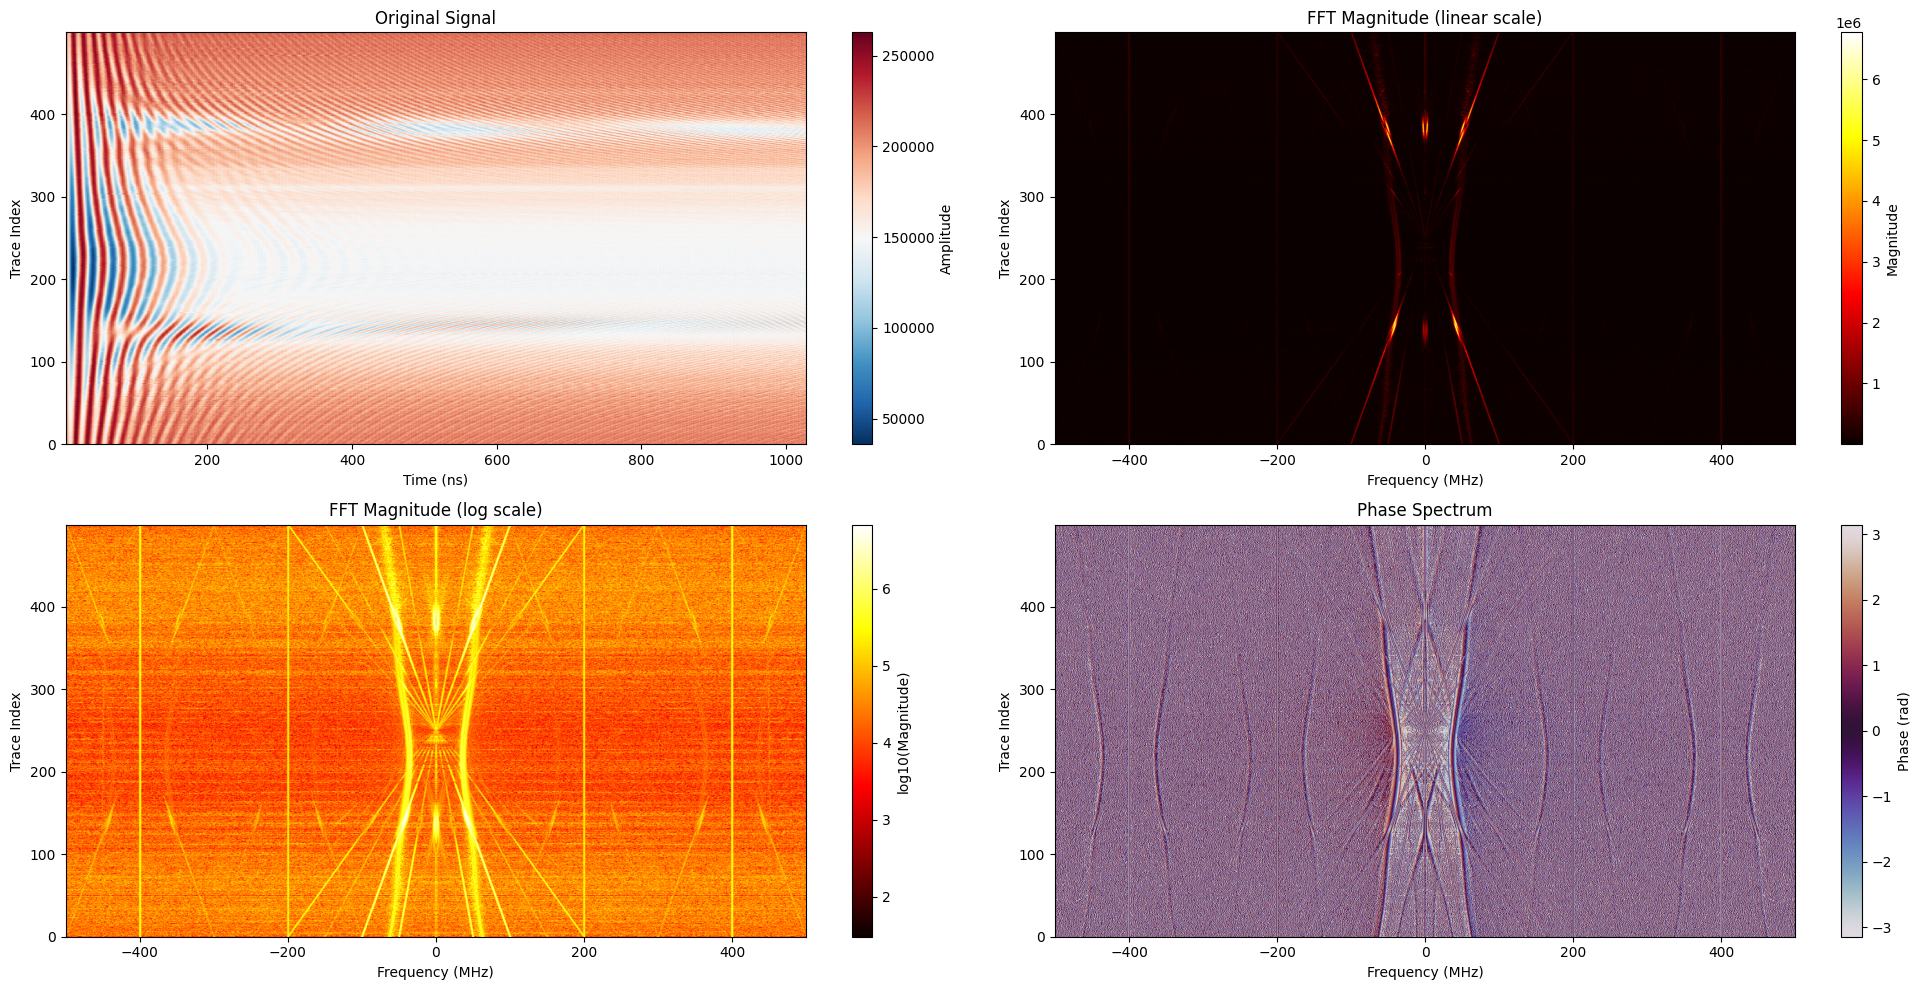

In [4]:
filename_2d = data_path / 'Rabi2D_GdCaWO4_6dB_3770G_2.DSC'
x_2d, y_2d, params, _ = epyr.eprload(filename_2d,return_type='real')

result = analyze_frequencies_2d(x_2d[0], y_2d, mode='row_by_row',
                                 window='kaiser', plot_result=True)

In [8]:
result[3]

{'mode': 'row_by_row',
 'axis': 1,
 'time_unit': 'ns',
 'freq_unit': 'MHz',
 'sampling_rate': np.float64(999999999.9999999),
 'time_data': array([   4.,    5.,    6., ..., 1025., 1026., 1027.], shape=(1024,)),
 'dc_removed': True,
 'window': 'kaiser',
 'zero_padding': 2,
 'phase_spectrum': array([[-0.        ,  2.58844633,  0.58894547, ...,  1.41911129,
         -0.58894547, -2.58844633],
        [-0.        , -1.67759669,  2.90171068, ..., -1.10290865,
         -2.90171068,  1.67759669],
        [-0.        , -0.97538406, -2.29592973, ..., -2.53529919,
          2.29592973,  0.97538406],
        ...,
        [-0.        , -2.87443339,  1.86204047, ..., -0.37938215,
         -1.86204047,  2.87443339],
        [-3.14159265,  2.18087684,  0.62679928, ...,  1.12458405,
         -0.62679928, -2.18087684],
        [-3.14159265,  1.52231242, -0.07587708, ...,  1.63328072,
          0.07587708, -1.52231242]], shape=(500, 2048))}